In [1]:
from src.OLS import OLS
from src.stat_tests import RESET, VIF

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
data_kw = {'encoding': 'utf-8', 'low_memory': False}

rgdp = pd.read_csv('data/fred/GDPC1.csv', **data_kw)
pce = pd.read_csv('data/fred/PCECC96.csv', **data_kw)
pdi = pd.read_csv('data/fred/GPDIC1.csv', **data_kw)
govexp = pd.read_csv('data/fred/GCEC1.csv', **data_kw)
odef = pd.read_csv('data/fred/GDPDEF.csv', **data_kw)

unat = pd.read_csv('data/fred/NROU.csv', **data_kw)
unrate = pd.read_csv('data/fred/LRUN64TTUSQ156S.csv', **data_kw)
ugap = pd.DataFrame(
    {
    "UGAP": unrate['LRUN64TTUSQ156S'] - unat['NROU'],
    'observation_date': unrate['observation_date']
    }
)

gdp_pot = pd.read_csv('data/fred/GDPPOT.csv', **data_kw)
ogap = pd.DataFrame({
    "OGAP": np.log(rgdp['GDPC1']) - np.log(gdp_pot['GDPPOT']),
    'observation_date': rgdp['observation_date']
})

netexp = pd.read_csv('data/fred/NETEXC.csv', **data_kw)
netexp['NETEXC'] = netexp['NETEXC'] / rgdp['GDPC1']
# Interactions
okun = pd.DataFrame({
    "UGAP_OGAP": ugap['UGAP'] * ogap['OGAP'],
    'observation_date': rgdp['observation_date']
})

philips = pd.DataFrame({
    "PHILIPS": ugap['UGAP'] * np.log(odef['GDPDEF']).diff(),
    'observation_date': rgdp['observation_date']
})

In [136]:
set = [
    rgdp,
    pce,
    pdi,
    govexp,
    odef,
    netexp,
    ugap,
    ogap,
    okun,
    philips,
]
regressors = set[1:]
for df in set:
    df['observation_date'] = pd.to_datetime(df['observation_date'])
    df.set_index('observation_date', inplace=True)
target = np.log(rgdp).diff().dropna()

In [137]:

fmt_regressors = [
    np.log(pce).diff().loc[target.index],
    np.log(pdi).diff().loc[target.index],
    np.log(govexp).diff().loc[target.index],
    netexp.diff().loc[target.index],
    ugap.loc[target.index],
    ogap.loc[target.index],
    okun.loc[target.index],
    philips.loc[target.index],
]
X = pd.concat(fmt_regressors, axis=1).shift(1).dropna()
t_idx = X.index
y = target.loc[t_idx]

In [138]:
fit = OLS(
    X=X.values,
    y=y.values.flatten(),
).fit(diagnosis_alpha=0.05, diagnosis_trend='c')
fit.error

R2: 0.36
R2_ADJ: 0.2448
RMSE: 0.0043
MAPE: 0.6954

In [139]:
RESET(
    X=X,
    y=y.values.flatten(),
    q=2
)

reject: False
pval: 0.9361357246551513
test_stat: 0.06608377187821031
stat_name: RESET Test (F-Statistic)

In [140]:
t = {'_const': fit.T_tests[0]}
for i, var in enumerate(X.columns):
    t[var] = fit.T_tests[i+1]
t

{'_const': reject: True
 pval: 0.0334369825023857
 test_stat: 2.1859234648597266
 stat_name: Coefficient Significance Test (T-Statistic),
 'PCECC96': reject: True
 pval: 0.00569542348955143
 test_stat: 2.8867404194955344
 stat_name: Coefficient Significance Test (T-Statistic),
 'GPDIC1': reject: False
 pval: 0.887047723980435
 test_stat: 0.1427530461296731
 stat_name: Coefficient Significance Test (T-Statistic),
 'GCEC1': reject: False
 pval: 0.798966269077478
 test_stat: 0.25601868059824634
 stat_name: Coefficient Significance Test (T-Statistic),
 'NETEXC': reject: False
 pval: 0.199635318323426
 test_stat: 1.2994432530670188
 stat_name: Coefficient Significance Test (T-Statistic),
 'UGAP': reject: False
 pval: 0.901323790180521
 test_stat: 0.12460795607997689
 stat_name: Coefficient Significance Test (T-Statistic),
 'OGAP': reject: True
 pval: 0.0394031207612446
 test_stat: 2.114252327037968
 stat_name: Coefficient Significance Test (T-Statistic),
 'UGAP_OGAP': reject: False
 pval: 0

In [141]:
fit.F_test

reject: True
pval: 0.004638755477769929
test_stat: 3.125427505583384
stat_name: F Test (F-Statistic)

In [142]:
VIF(X)

array([1.32151973, 1.34849101, 1.27865858, 1.41340712, 1.6560703 ,
       1.87375367, 2.73532825, 2.13877762])

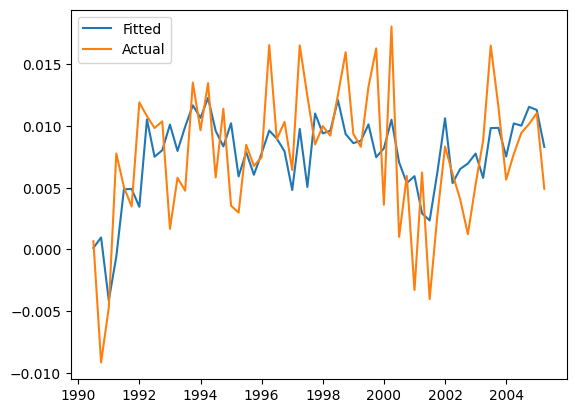

In [143]:
plt.plot(t_idx, fit.fitted_values, label='Fitted')
plt.plot(t_idx, y, label='Actual')
plt.legend()